# Specific Stock Simulation

Get the historical daily data for one ticker, run the prediction analysis across the full history, simulate trades from the resulting daily signals, and show a consolidated chart with price, trade markers, and portfolio value.

Trading rules:
- `STRONG BUY`: buy stock worth 10% of `initial_funds`
- `WEAK BUY`: buy stock worth 5% of `initial_funds`
- `HOLD`: do nothing
- `WEAK SELL`: sell 5% of current holdings
- `STRONG SELL`: sell 10% of current holdings

Fractional shares are allowed.


In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import analysis_blocks


## Block 1: Parameters


In [34]:
ticker = "PDD"
initial_funds = 10000
include_fundamentals = True
include_sentiment = False  # True requires API keys and adds latency


In [35]:
df_pred = analysis_blocks.build_prediction_and_stats(
            ticker,
            include_sentiment=include_sentiment
        )

In [36]:
df_pred

,Date,Open,High,Low,Close,Adj Close,Volume,TICKER,SMA10,SMA20,...,VWAP,Daily_Return,Cumulative_Return,Daily Gain/Loss,technical_analysis_buy_score,technical_analysis_sell_score,fundamental_analysis_score,sentiment_analysis_score,Signal,Signal_Text
0,2026-03-13,102.529999,103.620003,102.129997,102.650002,102.650002,4742908,PDD,NaN,NaN,...,102.650002,NaN,NaN,0.120003,0.00,-0.04,0.8875,0,1.1745,STRONG BUY
1,2026-03-12,102.529999,103.889999,101.389999,101.620003,101.620003,6350800,PDD,NaN,NaN,...,102.060360,-0.010034,-0.010034,-0.909996,0.15,-0.07,0.8875,0,1.3785,STRONG BUY
2,2026-03-11,104.629997,104.750000,102.480003,102.940002,102.940002,4475300,PDD,NaN,NaN,...,102.313212,0.012990,0.002825,-1.689995,0.00,-0.22,0.8875,0,0.8685,WEAK BUY
3,2026-03-10,103.529999,106.570000,103.419998,104.860001,104.860001,7767100,PDD,NaN,NaN,...,103.160875,0.018652,0.021529,1.330002,0.03,-0.19,0.8875,0,0.9705,STRONG BUY
4,2026-03-09,101.010002,103.010002,99.680000,102.639999,102.639999,6374600,PDD,NaN,NaN,...,103.049119,-0.021171,-0.000097,1.629997,0.18,-0.04,0.8875,0,1.4805,STRONG BUY
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1251,2021-03-19,141.070007,143.029999,138.199997,141.800003,141.800003,9457000,PDD,134.278999,135.837999,...,94.042970,0.033905,0.381393,0.729996,0.02,-0.20,0.8875,0,0.9365,STRONG BUY
1252,2021-03-18,144.710007,146.029999,140.520004,141.820007,141.820007,12125200,PDD,134.068000,136.263500,...,94.089404,0.000141,0.381588,-2.889999,0.02,-0.20,0.8875,0,0.9365,STRONG BUY
1253,2021-03-17,152.399994,153.000000,140.360001,149.460007,149.460007,27357800,PDD,135.626000,137.117500,...,94.210556,0.053871,0.456016,-2.939987,0.04,-0.18,0.8875,0,1.0045,STRONG BUY
1254,2021-03-16,166.800003,169.449997,158.699997,160.889999,160.889999,10963900,PDD,138.171000,138.531500,...,94.268974,0.076475,0.567365,-5.910004,0.05,-0.20,0.8875,0,0.9875,STRONG BUY


## Block 4: Simulate Daily Buy/Sell/Hold Strategy


In [37]:
simulation_result = analysis_blocks.simulate_prediction_signal_strategy(
    df_pred,
    initial_funds=initial_funds,
)


## Block 5: Portfolio Summary


In [38]:
simulation_result["price_history"]

,Date,Open,Close,Trade_Price
0,2021-03-15,158.699997,159.130005,158.915001
1,2021-03-16,166.800003,160.889999,163.845001
2,2021-03-17,152.399994,149.460007,150.930000
3,2021-03-18,144.710007,141.820007,143.265007
4,2021-03-19,141.070007,141.800003,141.435005
...,...,...,...,...
1251,2026-03-09,101.010002,102.639999,101.825001
1252,2026-03-10,103.529999,104.860001,104.195000
1253,2026-03-11,104.629997,102.940002,103.785000
1254,2026-03-12,102.529999,101.620003,102.075001


In [39]:
simulation_result["daily_history"]

,Date,Open,Close,Trade_Price,signal_text,signal_number,action,trade_units,trade_value,cash_balance,units_held,average_cost_per_unit,holdings_value,portfolio_value,profit_loss,profit_loss_pct
0,2021-03-15,158.699997,159.130005,158.915001,STRONG BUY,2,BUY,62.926721,10000.0,0.0,62.926721,158.915001,1.001353e+04,10013.529495,13.529495,0.135295
1,2021-03-16,166.800003,160.889999,163.845001,STRONG BUY,2,BUY,6.103329,1000.0,-1000.0,69.030051,159.350890,1.110624e+04,10106.244830,106.244830,1.062448
2,2021-03-17,152.399994,149.460007,150.930000,STRONG BUY,2,BUY,6.625588,1000.0,-2000.0,75.655639,158.613425,1.130749e+04,9307.492283,-692.507717,-6.925077
3,2021-03-18,144.710007,141.820007,143.265007,STRONG BUY,2,BUY,6.980072,1000.0,-3000.0,82.635710,157.316975,1.171940e+04,8719.397047,-1280.602953,-12.806030
4,2021-03-19,141.070007,141.800003,141.435005,STRONG BUY,2,BUY,7.070385,1000.0,-4000.0,89.706096,156.065202,1.272032e+04,8720.324656,-1279.675344,-12.796753
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1251,2026-03-09,101.010002,102.639999,101.825001,STRONG BUY,2,BUY,9.820771,1000.0,-1197500.0,13921.528046,86.736168,1.428906e+06,231405.630153,221405.630153,2214.056302
1252,2026-03-10,103.529999,104.860001,104.195000,STRONG BUY,2,BUY,9.597390,1000.0,-1198500.0,13931.125436,86.748196,1.460818e+06,262317.821682,252317.821682,2523.178217
1253,2026-03-11,104.629997,102.940002,103.785000,WEAK BUY,1,BUY,4.817652,500.0,-1199000.0,13935.943088,86.754086,1.434566e+06,235566.015451,225566.015451,2255.660155
1254,2026-03-12,102.529999,101.620003,102.075001,STRONG BUY,2,BUY,9.796718,1000.0,-1200000.0,13945.739806,86.764848,1.417166e+06,217166.117341,207166.117341,2071.661173


In [40]:
simulation_result["transactions"]


,Date,action,signal_text,trade_price,units,trade_value,cash_balance,units_held,portfolio_value
0,2021-03-15,BUY,STRONG BUY,158.915001,62.926721,10000.0,0.0,62.926721,10013.529495
1,2021-03-16,BUY,STRONG BUY,163.845001,6.103329,1000.0,-1000.0,69.030051,10106.244830
2,2021-03-17,BUY,STRONG BUY,150.930000,6.625588,1000.0,-2000.0,75.655639,9307.492283
3,2021-03-18,BUY,STRONG BUY,143.265007,6.980072,1000.0,-3000.0,82.635710,8719.397047
4,2021-03-19,BUY,STRONG BUY,141.435005,7.070385,1000.0,-4000.0,89.706096,8720.324656
...,...,...,...,...,...,...,...,...,...
1246,2026-03-09,BUY,STRONG BUY,101.825001,9.820771,1000.0,-1197500.0,13921.528046,231405.630153
1247,2026-03-10,BUY,STRONG BUY,104.195000,9.597390,1000.0,-1198500.0,13931.125436,262317.821682
1248,2026-03-11,BUY,WEAK BUY,103.785000,4.817652,500.0,-1199000.0,13935.943088,235566.015451
1249,2026-03-12,BUY,STRONG BUY,102.075001,9.796718,1000.0,-1200000.0,13945.739806,217166.117341


In [41]:
simulation_result["summary"]


,start_date,end_date,initial_funds,ending_cash_balance,units_held,average_cost_per_unit,latest_close,holdings_value,total_portfolio_value,profit_loss,profit_loss_pct,buy_transactions,sell_transactions
0,2021-03-15,2026-03-13,10000.0,-1201000.0,13955.487344,86.775902,102.650002,1.432531e+06,231530.797183,221530.797183,2215.307972,1251,0


## Block 6: Consolidated Chart


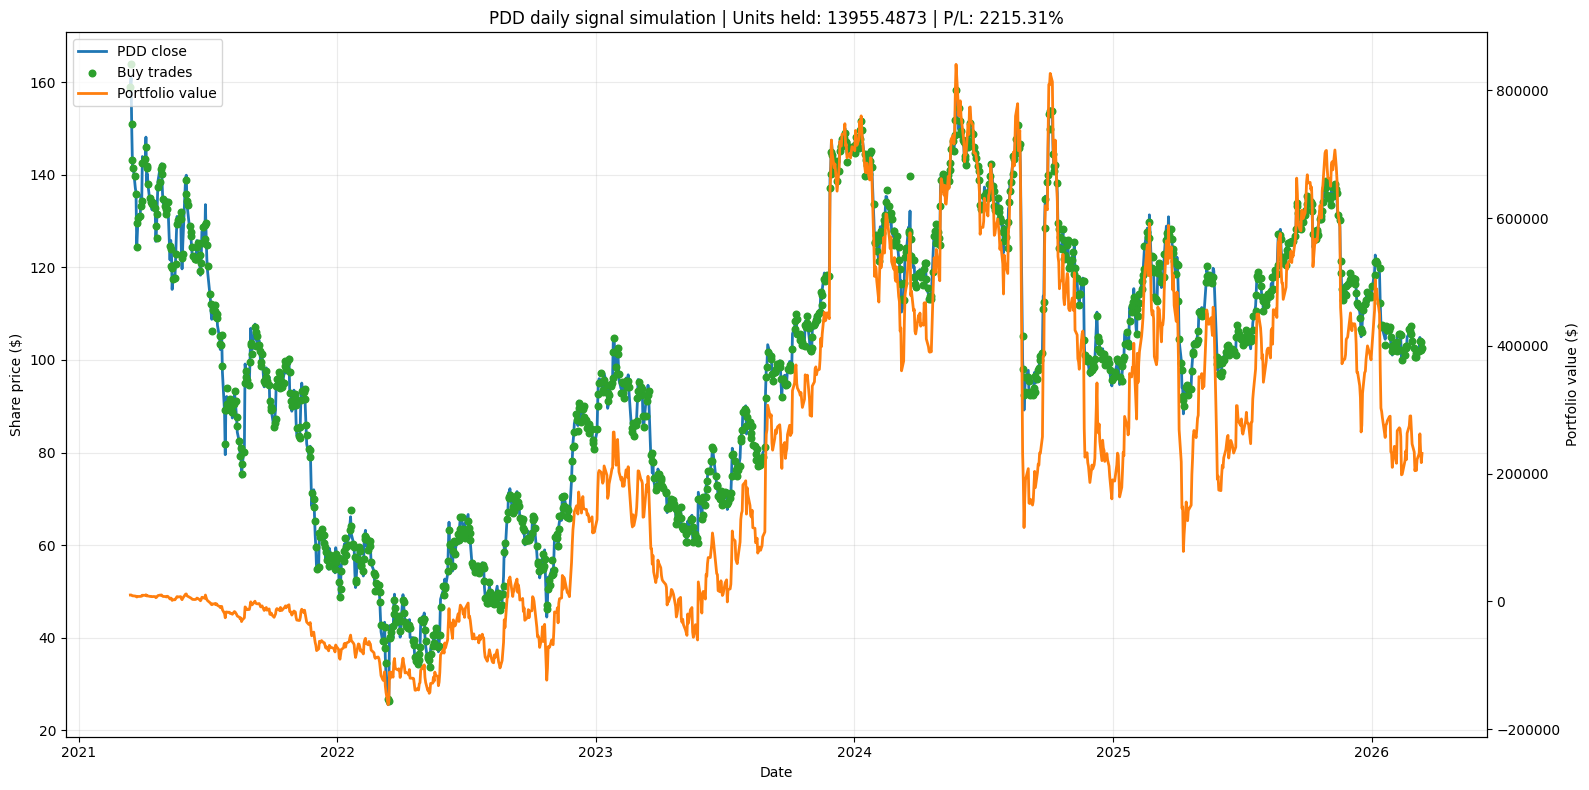

In [42]:
price_history = simulation_result["price_history"].copy()
daily_history = simulation_result["daily_history"].copy()
transactions = simulation_result["transactions"].copy()
simulation_summary = simulation_result["summary"].iloc[0]

buy_txns = transactions[transactions["action"] == "BUY"].copy()
sell_txns = transactions[transactions["action"] == "SELL"].copy()

fig, ax_price = plt.subplots(figsize=(16, 8))
ax_price.plot(
    price_history["Date"],
    price_history["Close"],
    color="#1f77b4",
    linewidth=2,
    label=f"{ticker} close",
)

if not buy_txns.empty:
    ax_price.scatter(
        buy_txns["Date"],
        buy_txns["trade_price"],
        color="#2ca02c",
        marker=".",
        s=90,
        label="Buy trades",
        zorder=5,
    )

if not sell_txns.empty:
    ax_price.scatter(
        sell_txns["Date"],
        sell_txns["trade_price"],
        color="#d62728",
        marker="v",
        s=90,
        label="Sell trades",
        zorder=5,
    )

ax_price.set_xlabel("Date")
ax_price.set_ylabel("Share price ($)")
ax_price.grid(alpha=0.25)

ax_portfolio = ax_price.twinx()
ax_portfolio.plot(
    daily_history["Date"],
    daily_history["portfolio_value"],
    color="#ff7f0e",
    linewidth=2,
    label="Portfolio value",
)
ax_portfolio.set_ylabel("Portfolio value ($)")

title = (
    f"{ticker} daily signal simulation | "
    f"Units held: {simulation_summary['units_held']:.4f} | "
    f"P/L: {simulation_summary['profit_loss_pct']:.2f}%"
)
ax_price.set_title(title)

handles_price, labels_price = ax_price.get_legend_handles_labels()
handles_portfolio, labels_portfolio = ax_portfolio.get_legend_handles_labels()
ax_price.legend(handles_price + handles_portfolio, labels_price + labels_portfolio, loc="upper left")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Block 7: Daily Portfolio History


In [33]:
simulation_result["daily_history"][[
    "Date",
    "signal_text",
    "action",
    "trade_units",
    "trade_value",
    "cash_balance",
    "units_held",
    "holdings_value",
    "portfolio_value",
    "profit_loss_pct",
]].tail(60)


,Date,signal_text,action,trade_units,trade_value,cash_balance,units_held,holdings_value,portfolio_value,profit_loss_pct
1196,2025-12-16,HOLD,HOLD,0.0,0.0,-22000.0,170.3648,83458.309021,61458.309021,514.583090
1197,2025-12-17,HOLD,HOLD,0.0,0.0,-22000.0,170.3648,79604.658079,57604.658079,476.046581
1198,2025-12-18,HOLD,HOLD,0.0,0.0,-22000.0,170.3648,82349.232510,60349.232510,503.492325
1199,2025-12-19,HOLD,HOLD,0.0,0.0,-22000.0,170.3648,81979.543806,59979.543806,499.795438
1200,2025-12-22,HOLD,HOLD,0.0,0.0,-22000.0,170.3648,83262.390541,61262.390541,512.623905
1201,2025-12-23,HOLD,HOLD,0.0,0.0,-22000.0,170.3648,82722.331838,60722.331838,507.223318
1202,2025-12-24,HOLD,HOLD,0.0,0.0,-22000.0,170.3648,82695.072846,60695.072846,506.950728
1203,2025-12-26,HOLD,HOLD,0.0,0.0,-22000.0,170.3648,80955.649694,58955.649694,489.556497
1204,2025-12-29,HOLD,HOLD,0.0,0.0,-22000.0,170.3648,78306.479135,56306.479135,463.064791
1205,2025-12-30,HOLD,HOLD,0.0,0.0,-22000.0,170.3648,77418.874784,55418.874784,454.188748
